# Interactive Business Dashboard - Global Superstore
## Exploratory Data Analysis and Business Insights

## 1. Problem Statement and Objective

Retail businesses generate large volumes of transactional data across regions, product categories, and customer segments. Without structured analysis, patterns in sales performance, profitability, and customer behavior remain hidden.

This project analyzes the Global Superstore dataset to uncover key business insights and presents them through an interactive Streamlit dashboard. The objective is to help business stakeholders monitor KPIs, compare segment performance, and identify high value customers through interactive filters and visualizations.

## 2. Dataset Description

The dataset is the Global Superstore dataset containing retail order data across multiple markets and regions.

- **Source:** Global Superstore Excel file with 3 sheets: Orders, Returns, People
- **Orders sheet:** 51,290 rows and 24 columns covering order details, customer info, product info, and financials
- **Returns sheet:** Contains Order IDs of returned orders
- **People sheet:** Maps regional managers to regions
- **Time period:** 2011 to 2014
- **Key columns:** Order ID, Order Date, Customer Name, Segment, Region, Category, Sub Category, Sales, Quantity, Discount, Profit, Shipping Cost

## 3. Import Libraries and Load Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders = pd.read_excel('Global Superstore.xls', sheet_name='Orders', engine='xlrd')
returns = pd.read_excel('Global Superstore.xls', sheet_name='Returns', engine='xlrd')
people = pd.read_excel('Global Superstore.xls', sheet_name='People', engine='xlrd')

print('Orders shape:', orders.shape)
print('Returns shape:', returns.shape)
print('People shape:', people.shape)

Orders shape: (51290, 24)
Returns shape: (1173, 3)
People shape: (13, 2)


## 4. Data Cleaning and Preprocessing

In [4]:
# Check for missing values
print('Missing values per column:')
print(orders.isnull().sum())

Missing values per column:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [5]:
# Postal Code has 41,296 missing values. this column is not used in analysis so we drop it
orders.drop(columns=['Postal Code'], inplace=True)

# Convert date columns to datetime
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])

# Extract year from Order Date
orders['Order Year'] = orders['Order Date'].dt.year

# Calculate profit margin
orders['Profit Margin'] = (orders['Profit'] / orders['Sales'] * 100).round(2)

# Merge returns information
orders['Returned'] = orders['Order ID'].isin(returns['Order ID']).map({True: 'Yes', False: 'No'})

# Merge regional manager info
df = orders.merge(people, on='Region', how='left')

print('Final dataset shape:', df.shape)
print('Duplicate rows:', df.duplicated().sum())

Final dataset shape: (51290, 27)
Duplicate rows: 0


In [6]:
# Preview cleaned data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Order Year,Profit Margin,Returned,Person
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2309.650,7,0.0,762.1845,933.57,Critical,2012,33.00,No,Kelly Williams
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,3709.395,9,0.1,-288.7650,923.63,Critical,2013,-7.78,Yes,Anthony Jacobs
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,5175.171,9,0.1,919.9710,915.49,Medium,2013,17.78,No,Anthony Jacobs
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,2892.510,5,0.1,-96.5400,910.16,Medium,2013,-3.34,No,Anna Andreadi
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,2832.960,8,0.0,311.5200,903.04,Critical,2013,11.00,No,Deborah Brumfield


## 5. Exploratory Data Analysis

### 5.1 Overall Business KPIs

In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer Name'].nunique()
return_rate = (df['Returned'] == 'Yes').sum() / len(df) * 100

print(f'Total Sales:      ${total_sales:,.2f}')
print(f'Total Profit:     ${total_profit:,.2f}')
print(f'Total Orders:     {total_orders:,}')
print(f'Total Customers:  {total_customers:,}')
print(f'Return Rate:      {return_rate:.2f}%')

Total Sales:      $12,642,501.91
Total Profit:     $1,467,457.29
Total Orders:     25,035
Total Customers:  795
Return Rate:      5.95%


The business generated over 12.6 million dollars in sales between 2011 and 2014 with a total profit of approximately 1.47 million dollars. The overall profit margin is around 11.6 percent.

### 5.2 Sales and Profit by Category

In [8]:
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Sales', ascending=False)

cat_summary['Profit Margin %'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(2)
print(cat_summary)

                  Total_Sales  Total_Profit  Profit Margin %
Category                                                    
Technology       4.744557e+06  663778.73318            13.99
Furniture        4.110874e+06  285204.72380             6.94
Office Supplies  3.787070e+06  518473.83430            13.69


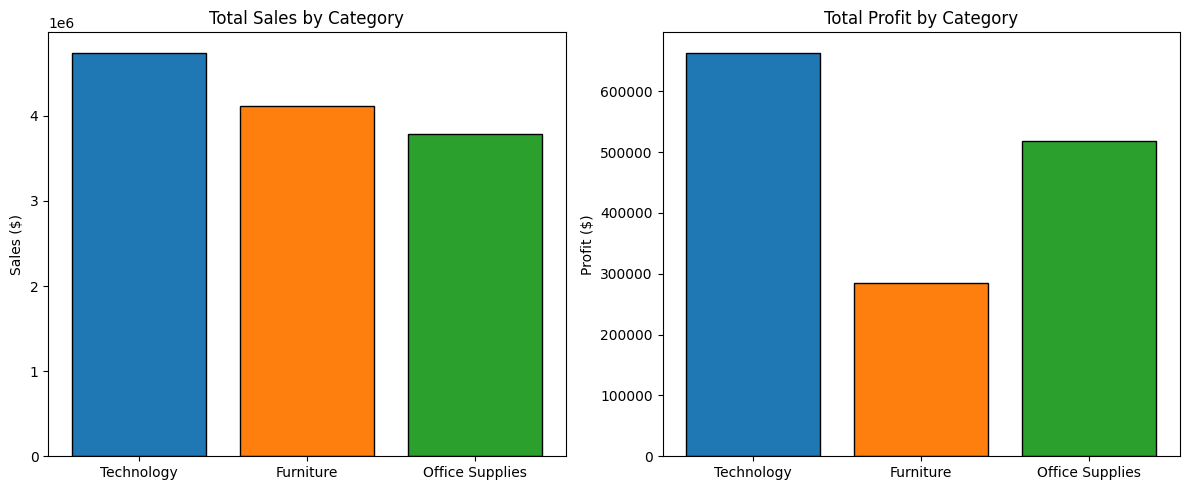

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(cat_summary.index, cat_summary['Total_Sales'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(cat_summary.index, cat_summary['Total_Profit'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

Technology leads in both sales (4.74M) and profit (663K). Furniture generates high sales (4.11M) but has the lowest profit margin among all three categories, suggesting heavy discounting or high cost of goods. Office Supplies has a relatively strong profit margin despite lower sales volume.

### 5.3 Sales by Customer Segment

In [10]:
seg_summary = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False)

print(seg_summary)

              Total_Sales  Total_Profit  Orders
Segment                                        
Consumer     6.507949e+06  749239.78206   13104
Corporate    3.824698e+06  441208.32866    7673
Home Office  2.309855e+06  277009.18056    4687


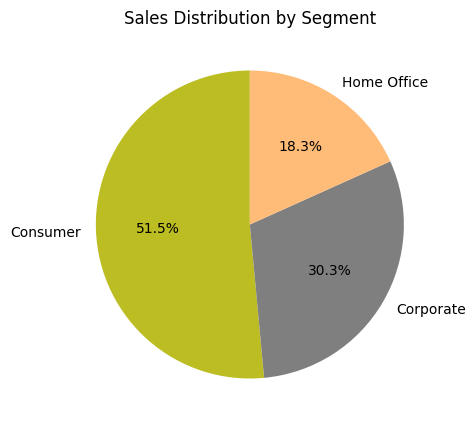

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(seg_summary['Total_Sales'], labels=seg_summary.index, autopct='%1.1f%%',
       colors=['#bcbd22', '#7f7f7f', '#ffbb78'], startangle=90)
ax.set_title('Sales Distribution by Segment')
plt.show()

The Consumer segment accounts for the largest share of sales at 51.5 percent, followed by Corporate at 30.3 percent and Home Office at 18.3 percent. All three segments are profitable.

### 5.4 Sales Trend Over Time

In [12]:
yearly = df.groupby('Order Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

print(yearly)

   Order Year   Total_Sales  Total_Profit
0        2011  2.259451e+06  248940.81154
1        2012  2.677439e+06  307415.27910
2        2013  3.405746e+06  406935.23018
3        2014  4.299866e+06  504165.97046


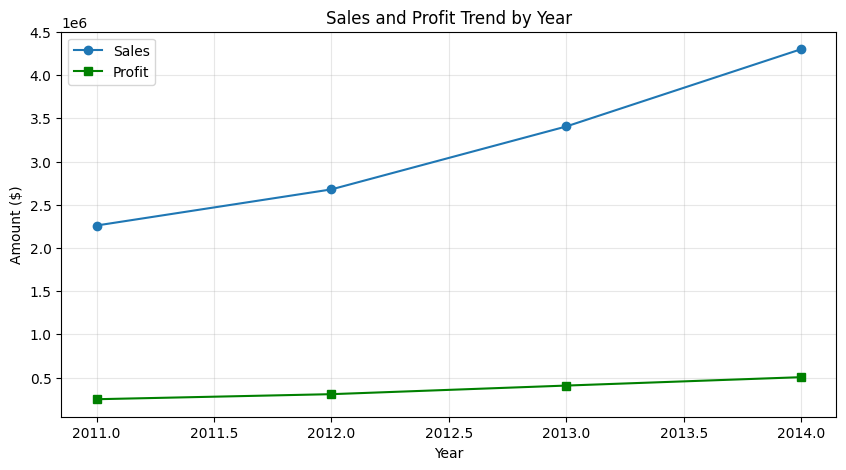

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly['Order Year'], yearly['Total_Sales'], marker='o', color='#1f77b4', label='Sales')
ax.plot(yearly['Order Year'], yearly['Total_Profit'], marker='s', color='green', label='Profit')
ax.set_xlabel('Year')
ax.set_ylabel('Amount ($)')
ax.set_title('Sales and Profit Trend by Year')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Sales show a consistent upward trend from 2011 to 2014. Profit also grows year over year, which indicates the business is scaling while maintaining margins.

### 5.5 Top 5 Customers by Sales

In [14]:
top_customers = df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False).head(5)

print(top_customers)

                    Total_Sales  Total_Profit  Orders
Customer Name                                        
Tom Ashbrook        40488.07080    6311.97910      30
Tamara Chand        37457.33300    8672.89890      36
Greg Tran           35550.95428    5214.13118      34
Christopher Conant  35187.07640    5603.33370      39
Sean Miller         35170.93296    -409.70634      28


Tom Ashbrook is the highest spending customer with over 40,000 dollars in total sales. The top 5 customers all exceed 35,000 dollars in sales, making them high-value accounts worth retaining through targeted marketing.

### 5.6 Regional Performance

In [15]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Sales', ascending=False)

print(region_summary.head(8))

                 Total_Sales  Total_Profit
Region                                    
Central         2.822303e+06  311403.98164
South           1.600907e+06  140355.76618
North           1.248166e+06  194597.95252
Oceania         1.100185e+06  120089.11200
Southeast Asia  8.844232e+05   17852.32900
North Asia      8.483098e+05  165578.42100
EMEA            8.061613e+05   43897.97100
Africa          7.837732e+05   88871.63100


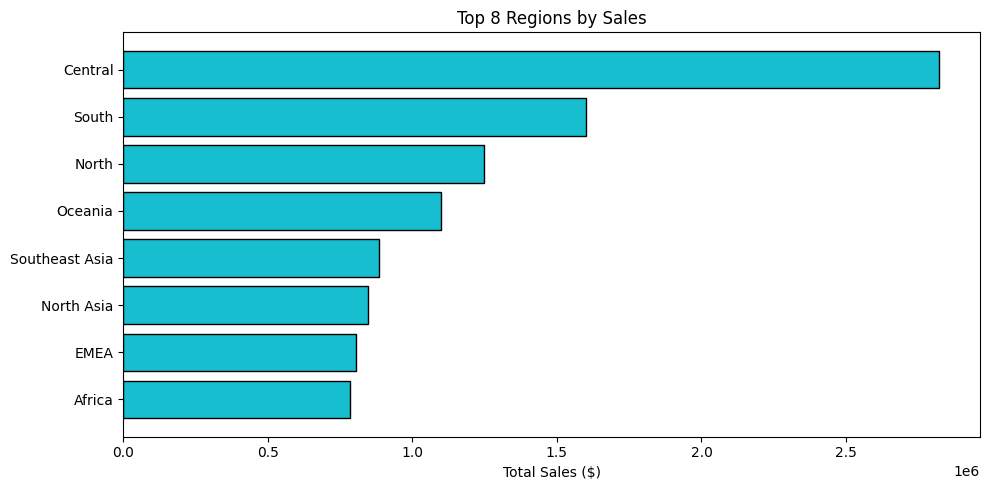

In [16]:
top_regions = region_summary.head(8)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_regions.index[::-1], top_regions['Total_Sales'][::-1], color='#17becf', edgecolor='black')
ax.set_xlabel('Total Sales ($)')
ax.set_title('Top 8 Regions by Sales')
plt.tight_layout()
plt.show()

## 6. Final Conclusions and Insights

1. Technology is the most profitable category and should remain the focus of marketing campaigns.

2. Furniture generates high sales volume but poor profit margins. Discounting strategy in this category needs to be reviewed.

3. The Consumer segment drives more than half of total revenue. Loyalty programs targeting this segment would have the highest impact.

4. Sales and profit have grown consistently from 2011 to 2014, indicating healthy business performance.

5. A small group of high-value customers such as Tom Ashbrook and Tamara Chand contribute disproportionately to revenue. Retention strategies for these customers are critical.

6. Regional performance varies significantly. Identifying underperforming regions and investigating root causes can unlock growth opportunities.

These insights are presented interactively in the Streamlit dashboard where users can filter by region, category, sub category, year, and regional manager to explore the data dynamically.